In [1]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd /Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow

/Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow


In [2]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity
from RFsampler_modules import MyEulerSampler, MytrueEulerSampler, Mynew_trueSDESampler, MynewSDESampler

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
import numpy as np
from RFsampler_modules import MynewSDE_timegrid_generator, Mynew_trueSDESampler

def geom_timegrid_generator(NUM_STEPS, delta):
    geom_timegrid = np.zeros(NUM_STEPS + 1)
    h = np.exp(2/(NUM_STEPS-2) * np.log(1/(2 * delta))) - 1.0
    # First partition [0, 1/2]
    geom_timegrid[0] = 0
    geom_timegrid[1] = delta
    for j in range(2, NUM_STEPS // 2 + 1):
        geom_timegrid[j] = (1 + h) * geom_timegrid[j - 1]

    # Second partition [1/2, 1]
    geom_timegrid[NUM_STEPS] = 1.0
    geom_timegrid[NUM_STEPS - 1] = 1.0 - delta
    for j in range(NUM_STEPS - 2, NUM_STEPS // 2 - 1, -1):
        geom_timegrid[j] = 1.0 - (1 + h) * (1.0 - geom_timegrid[j + 1])
    geom_timegrid = torch.tensor(geom_timegrid, device = device)

    return geom_timegrid


lin_timegrid_generator = lambda NUM_STEPS: torch.linspace(0,1 , NUM_STEPS+1).to(device)

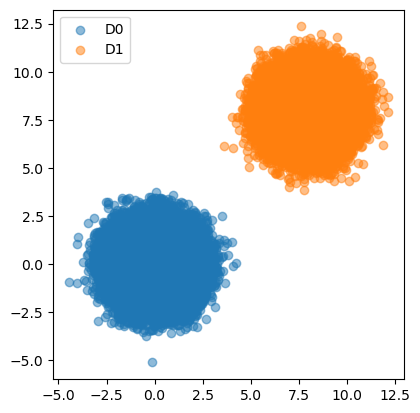

In [10]:
from sklearn.datasets import make_moons
from data_generator import generate_data
#####################################
n_samples = 50000
INPUT_DIM = 10
RANK = 2
CENTER = torch.ones(INPUT_DIM) * 8.0
TYPE = 'low_rank_Gaussian'  # 'low_rank_Gaussian' or 'two_moons'

NUM_STEPS = 200 # Number of time steps for sampling
NUM_SAMPLES = 2000 # Number of samples to Generate
#####################################

pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
D0 = pi_0.sample([n_samples])  
pi_1 = generate_data
D1 = pi_1(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)




plt.scatter(D0[:, 0].cpu().numpy(), D0[:, 1].cpu().numpy(), alpha=0.5, label='D0')
plt.scatter(D1[:, 0].cpu().numpy(), D1[:, 1].cpu().numpy(), alpha=0.5, label='D1')
plt.legend()
#plt.xlim(-5, 18)
#plt.ylim(-8, 8)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


# Generating two moon dataset for training
       


Epoch [1/20000], loss: 70.6112
Epoch [501/20000], loss: 1.1090
Epoch [1001/20000], loss: 0.4789
Epoch [1501/20000], loss: 0.4351
Epoch [2001/20000], loss: 0.3816
Epoch [2501/20000], loss: 0.3850
Epoch [3001/20000], loss: 0.3745
Epoch [3501/20000], loss: 0.3532
Epoch [4001/20000], loss: 0.3593
Epoch [4501/20000], loss: 0.3516
Epoch [5001/20000], loss: 0.3298
Epoch [5501/20000], loss: 0.3533
Epoch [6001/20000], loss: 0.3622
Epoch [6501/20000], loss: 0.3532
Epoch [7001/20000], loss: 0.3631
Epoch [7501/20000], loss: 0.3458
Epoch [8001/20000], loss: 0.3523
Epoch [8501/20000], loss: 0.3514
Epoch [9001/20000], loss: 0.3464
Epoch [9501/20000], loss: 0.3658
Epoch [10001/20000], loss: 0.3456
Epoch [10501/20000], loss: 0.3513
Epoch [11001/20000], loss: 0.3454
Epoch [11501/20000], loss: 0.3466
Epoch [12001/20000], loss: 0.3694
Epoch [12501/20000], loss: 0.3285
Epoch [13001/20000], loss: 0.3537
Epoch [13501/20000], loss: 0.3624
Epoch [14001/20000], loss: 0.3510
Epoch [14501/20000], loss: 0.3474
Epo

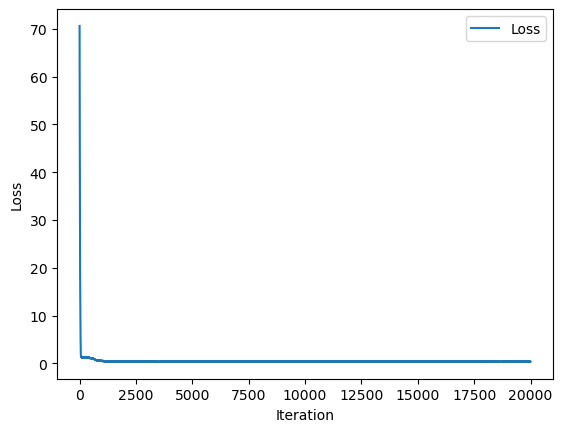

In [11]:
from RFmodules import rf_trainer
from rectified_flow.models.toy_mlp import MLPVelocity
from RFmodules import VelocityNet, VelocityNet2, NonlinearGatedVelocity

straight_rf = RectifiedFlow(
    data_shape=(INPUT_DIM,),
    velocity_field= NonlinearGatedVelocity(INPUT_DIM, hidden_dim=128).to(device),
    interp="straight",
    source_distribution=pi_0,
    device=device,
)

losses =rf_trainer(straight_rf, D0, D1, 'loss', num_epochs=20000)
plt.plot(losses, label= 'Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

# Main experiments

In [12]:
def check_assumption_4_4_mcmc(
    velocity_field, pi_0, pi_1, k, d,
    time_grid=None, n_samples=200, M=20, eta=None, device='cpu', h=1e-3, n_sup_samples=500
):
    if time_grid is None:
        time_grid = np.linspace(0.05, 0.92, 12)
    if eta is None:
        eta = 1.0 / len(time_grid)

    T = len(time_grid)
    all_a   = np.zeros((M, T))
    all_b   = np.zeros((M, T))
    all_c   = np.zeros((M, T))
    all_op  = np.zeros((M, T))
    all_lam = np.zeros((M, T))

    for m in range(M):
        print(f"  MCMC run {m+1}/{M} ...", end='\r')
        all_a[m], all_b[m], all_c[m], all_op[m], all_lam[m] = single_mcmc_run(
            velocity_field, pi_0, pi_1, k, d,
            time_grid, n_samples, eta, device, h, n_sup_samples
        )
    print()

    return dict(
        time_grid     = time_grid,
        mean_a=all_a.mean(0),    std_a=all_a.std(0),
        mean_b=all_b.mean(0),    std_b=all_b.std(0),
        mean_c=all_c.mean(0),    std_c=all_c.std(0),
        mean_op=all_op.mean(0),  std_op=all_op.std(0),
        mean_lam=all_lam.mean(0),std_lam=all_lam.std(0),
        eps_J1_sq     = all_a.mean(1).mean(),
        eps_J2_sq     = all_b.mean(1).mean(),
        eps_H_sq      = all_c.mean(1).mean(),
        eps_J1_sq_std = all_a.mean(1).std(),
        eps_J2_sq_std = all_b.mean(1).std(),
        eps_H_sq_std  = all_c.mean(1).std(),
        raw_a=all_a, raw_b=all_b, raw_c=all_c,
        raw_lam=all_lam,
    )


def plot_assumption_4_4(results, k, d):
    t  = results['time_grid']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))   # ← 4 panels now

    def _panel(ax, mean, std, color, label, title, ylabel,
               hline=None, hline_label=None, hline_color='k',
               twin_mean=None, twin_std=None, twin_label=None, twin_ylabel=None):
        ax.plot(t, mean, 'o-', color=color, label=label)
        ax.fill_between(t, mean - std, mean + std, alpha=0.25, color=color,
                        label='±1 std')
        if hline is not None:
            ax.axhline(hline, color=hline_color, linestyle='--', alpha=0.6, label=hline_label)
        if twin_mean is not None:
            ax2 = ax.twinx()
            ax2.plot(t, twin_mean, 's:', color='tab:red', alpha=0.8, label=twin_label)
            ax2.fill_between(t, twin_mean - twin_std, twin_mean + twin_std,
                             alpha=0.15, color='tab:red')
            ax2.set_ylabel(twin_ylabel, color='tab:red')
            ax2.tick_params(axis='y', labelcolor='tab:red')
            lines2, labels2 = ax2.get_legend_handles_labels()
        else:
            lines2, labels2 = [], []
        ax.set_xlabel('t'); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.grid(True, alpha=0.3)
        lines1, labels1 = ax.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

    _panel(axes[0],
           results['mean_a'], results['std_a'],
           color='tab:blue', label=r'$(\varepsilon_i^{J,1})^2$',
           title='Part (a): Frobenius Jacobian Error\n'
                 r'$\mathbb{E}\|\nabla v_t - \nabla\hat{v}_t\|_F^2$',
           ylabel=r'$(\varepsilon_i^{J,1})^2$',
           twin_mean=results['mean_op'], twin_std=results['std_op'],
           twin_label=r'$\eta\sup\|\cdot\|_{op}$',
           twin_ylabel='Op-norm condition')

    # threshold line at 1/8 on the twin axis — add manually
    axes[0].figure.axes[1].axhline(1/8, color='tab:red', linestyle='--',
                                    alpha=0.5, label='1/8 threshold')

    _panel(axes[1],
           results['mean_b'], results['std_b'],
           color='tab:green', label=r'$(\varepsilon_i^{J,2})^2$',
           title='Part (b): Divergence Error\n'
                 r'$\mathbb{E}[\mathrm{Tr}(\nabla v_t - \nabla\hat{v}_t)^2]$',
           ylabel=r'$(\varepsilon_i^{J,2})^2$')

    _panel(axes[2],
           results['mean_c'], results['std_c'],
           color='tab:purple', label=r'$(\varepsilon_i^{H})^2$',
           title='Part (c): Gradient-of-Divergence Error\n'
                 r'$\mathbb{E}\|\nabla\mathrm{Tr}(\nabla v_t - \nabla\hat{v}_t)\|_2^2$',
           ylabel=r'$(\varepsilon_i^{H})^2$')

    # ── Panel 4: min_x η·λ_min(Ĵ) with threshold at -1/4 ────────────────────
    _panel(axes[3],
       results['mean_lam'], results['std_lam'],
       color='tab:orange', label=r'$\min_x\,\eta\,\lambda_{\min}(\nabla\hat{v}_t(x))$',
       title=r'Eigenvalue condition: $\min_x\,\eta\,\lambda_{\min}(\nabla\hat{v}_t) \geq -1/4$',
       ylabel=r'$\min_x\,\eta\,\lambda_{\min}(\nabla\hat{v}_t)$',
       hline=-0.25, hline_label='Threshold -1/4', hline_color='tab:red')

    plt.suptitle(
        f'Assumption 4.4 — MCMC Estimates  (k={k}, d={d})\n'
        r'$X_t = t\,D_1 + (1-t)\,D_0$,  $D_0\sim p_0$,  $D_1\sim p_1$',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # ── summary ───────────────────────────────────────────────────────────────
    passes_op  = (results['mean_op']  <= 1/8).all()
    passes_lam = (results['mean_lam'] >= -1/4).all()
    print("\n" + "="*60)
    print("ASSUMPTION 4.4  —  MCMC SUMMARY")
    print("="*60)
    print(f"  N⁻¹Σ(εᵢᴶ·¹)²     = {results['eps_J1_sq']:.6f} ± {results['eps_J1_sq_std']:.6f}")
    print(f"  N⁻¹Σ(εᵢᴶ·²)²     = {results['eps_J2_sq']:.6f} ± {results['eps_J2_sq_std']:.6f}")
    print(f"  N⁻¹Σ(εᵢᴴ)²       = {results['eps_H_sq']:.6f}  ± {results['eps_H_sq_std']:.6f}")
    print(f"  sup op-norm ≤ 1/8? {'✓ PASS' if passes_op  else '✗ FAIL'}  "
          f"(max={results['mean_op'].max():.4f})")
    print(f"  min η·λ_min ≥−1/4? {'✓ PASS' if passes_lam else '✗ FAIL'}  "
          f"(min={results['mean_lam'].min():.4f})")
    print("="*60)

  MCMC run 5/5 ...


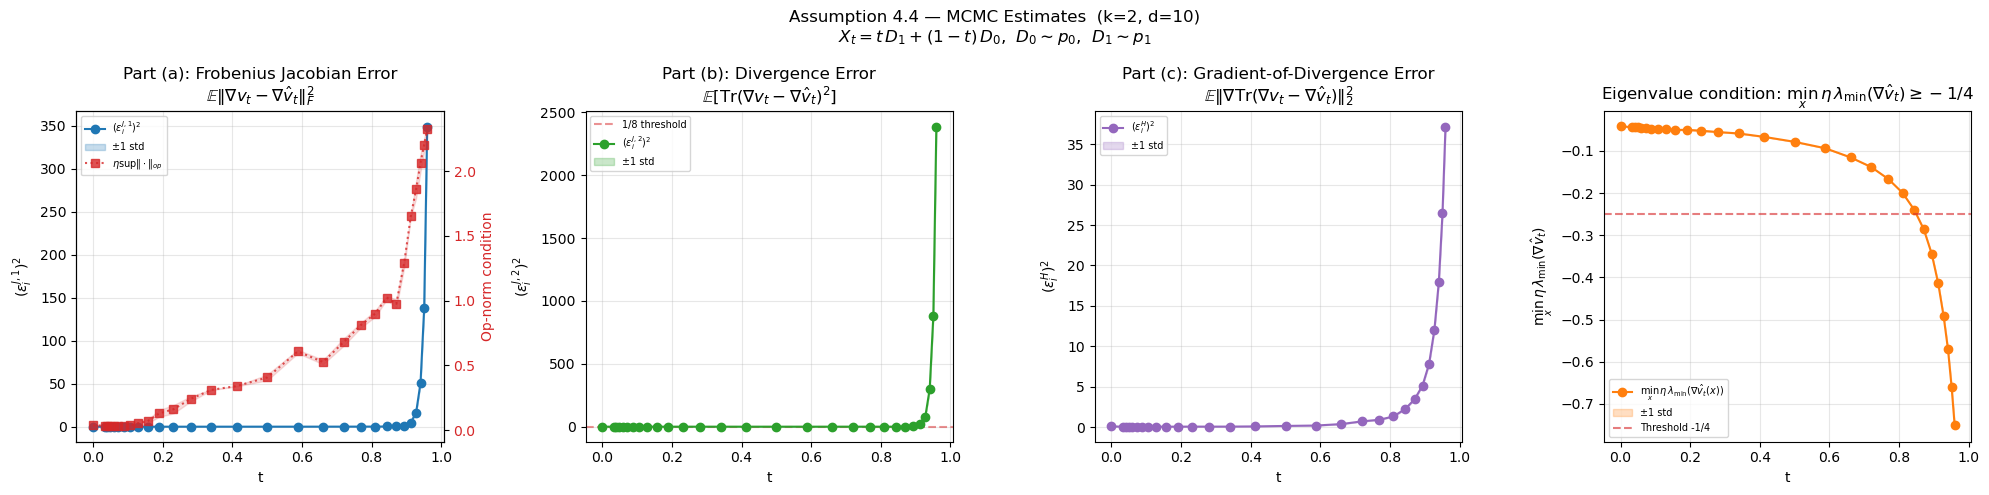


ASSUMPTION 4.4  —  MCMC SUMMARY
  N⁻¹Σ(εᵢᴶ·¹)²     = 19.383820 ± 0.048642
  N⁻¹Σ(εᵢᴶ·²)²     = 126.221038 ± 0.432896
  N⁻¹Σ(εᵢᴴ)²       = 4.031275  ± 0.013010
  sup op-norm ≤ 1/8? ✗ FAIL  (max=2.3208)
  min η·λ_min ≥−1/4? ✗ FAIL  (min=-0.7504)


In [13]:
# ── FIX 1: flexible velocity wrapper ─────────────────────────────────────────
# Wrap get_velocity so we don't care about its exact t-input format

def call_velocity(velocity_field, x, t_scalar, device):
    """
    Safely call velocity_field(x, t) regardless of whether it expects
    t as scalar, (1,), (n,1), or (n,) tensor.
    x: (n, d) or (1, d)
    Returns: (n, d)
    """
    n = x.shape[0]
    # try common formats in order
    t_opts = [
        torch.full((n, 1), t_scalar, device=device, dtype=torch.float32),
        torch.full((n,),   t_scalar, device=device, dtype=torch.float32),
        torch.tensor(t_scalar,       device=device, dtype=torch.float32),
        torch.full((1, 1), t_scalar, device=device, dtype=torch.float32),
    ]
    for t_in in t_opts:
        try:
            out = velocity_field(x, t_in)
            if out.shape == x.shape:
                return out
        except Exception:
            continue
    raise RuntimeError(
        f"Could not call velocity_field with x.shape={x.shape} at t={t_scalar}. "
        "Please set VELOCITY_T_FORMAT below to match your model's signature."
    )


# ── FIX 2: Jacobian using the wrapper ────────────────────────────────────────

def compute_jacobian_single(velocity_field, x_single, t_scalar, device):
    """
    Jacobian of v(x,t) w.r.t. x for a single sample x_single: (d,).
    Returns (d, d).
    """
    x = x_single.detach().unsqueeze(0).requires_grad_(True)   # (1, d)
    v = call_velocity(velocity_field, x, t_scalar, device)     # (1, d)
    d = x.shape[1]
    J = torch.zeros(d, d, device=device)
    for i in range(d):
        grad = torch.autograd.grad(v[0, i], x, retain_graph=(i < d - 1))[0]
        J[i] = grad[0]
    return J.detach()


def grad_div_fd(velocity_field, x_single, t_scalar, device, h=1e-3):
    """Central-FD gradient of divergence. ∇_x Tr(J(x)), shape (d,)."""
    d = x_single.shape[0]
    grad_div = torch.zeros(d, device=device)
    for j in range(d):
        e_j = torch.zeros(d, device=device); e_j[j] = h
        tr_p = compute_jacobian_single(velocity_field, x_single + e_j, t_scalar, device).trace()
        tr_m = compute_jacobian_single(velocity_field, x_single - e_j, t_scalar, device).trace()
        grad_div[j] = (tr_p - tr_m) / (2 * h)
    return grad_div


def compute_true_jacobian(t, k, d, device):
    sigma_sq = t**2 + (1 - t)**2
    c1 = (2*t - 1) / sigma_sq
    c2 = -1.0 / (1.0 - t)
    J = torch.zeros(d, d, device=device)
    J[:k, :k] = c1 * torch.eye(k, device=device)
    J[k:, k:] = c2 * torch.eye(d - k, device=device)
    return J


# ── FIX 3: accept D0, D1 tensors directly (resample rows each run) ───────────

# def single_mcmc_run(velocity_field, pi_0, pi_1, k, d, time_grid, n_samples, eta, device, h=1e-3):
#     """
#     pi_0: (N0, d) tensor of source samples  (pool to draw from)
#     pi_1: (N1, d) tensor of target samples  (pool to draw from)
#     For each t, draw fresh rows from pi_0/pi_1 to form X_t = t*pi_1_i + (1-t)*pi_0_i.
#     """
#     D0 = pi_0.sample([n_samples])  # (n_samples, d)
#     D1 = pi_1(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)  # (n_samples, d)
#     assert D0.shape[1] == d and D1.shape[1] == d, \
#         f"D0/D1 must have {d} columns, got {D0.shape[1]}/{D1.shape[1]}"
#     assert len(D0) >= n_samples and len(D1) >= n_samples, \
#         f"Need at least n_samples={n_samples} rows in D0/D1"

#     eps_a, eps_b, eps_c, op_norms_out = [], [], [], []

#     for t_val in time_grid:
#         # ── fresh random subsets ──────────────────────────────────────────────
#         idx0 = torch.randint(len(D0), (n_samples,))
#         idx1 = torch.randint(len(D1), (n_samples,))
#         d0   = D0[idx0].to(device)
#         d1   = D1[idx1].to(device)
#         X_t  = (1.0 - t_val) * d0 + t_val * d1      # (n_samples, d)

#         J_true     = compute_true_jacobian(t_val, k, d, device)
#         true_trace = J_true.trace().item()

#         frob_sq, trace_sq, gdiv_sq, op_list = [], [], [], []

#         for i in range(n_samples):
#             J_hat = compute_jacobian_single(velocity_field, X_t[i], t_val, device)
#             diff  = J_true - J_hat

#             # (a) Frobenius² and operator norm
#             frob_sq.append((diff**2).sum().item())
#             op_list.append(torch.linalg.matrix_norm(diff, ord=2).item())

#             # (b) trace error²
#             trace_sq.append((true_trace - J_hat.trace().item())**2)

#             # (c) ‖∇div(v̂)(x)‖²  (true ∇div = 0 since true trace is x-independent)
#             g = grad_div_fd(velocity_field, X_t[i], t_val, device, h=h)
#             gdiv_sq.append((g**2).sum().item())

#         eps_a.append(np.mean(frob_sq))
#         eps_b.append(np.mean(trace_sq))
#         eps_c.append(np.mean(gdiv_sq))
#         op_norms_out.append(eta * np.max(op_list))

#     return np.array(eps_a), np.array(eps_b), np.array(eps_c), np.array(op_norms_out)

def single_mcmc_run(velocity_field, pi_0, pi_1, k, d, time_grid, n_samples, eta, device, h=1e-3,
                    n_sup_samples=500):
    D0_full = pi_0.sample([n_sup_samples])
    D1_full = pi_1(TYPE, n_sup_samples, INPUT_DIM, RANK, CENTER, device=device)

    eps_a, eps_b, eps_c, op_norms_out, lam_min_out = [], [], [], [], []

    for t_val in time_grid:
        # ── X_t for expectation terms (a, b, c) ──────────────────────────────
        idx0 = torch.randint(len(D0_full), (n_samples,))
        idx1 = torch.randint(len(D1_full), (n_samples,))
        X_t  = (1.0 - t_val) * D0_full[idx0].to(device) + t_val * D1_full[idx1].to(device)

        # ── X_sup: pool across all t to approximate sup/inf over x ──────────
        sup_x_list = []
        for t_other in time_grid:
            i0 = torch.randint(len(D0_full), (n_sup_samples // len(time_grid) + 1,))
            i1 = torch.randint(len(D1_full), (n_sup_samples // len(time_grid) + 1,))
            x_other = (1.0 - t_other) * D0_full[i0].to(device) + t_other * D1_full[i1].to(device)
            sup_x_list.append(x_other)
        X_sup = torch.cat(sup_x_list, dim=0)

        J_true     = compute_true_jacobian(t_val, k, d, device)
        true_trace = J_true.trace().item()

        # ── sup_x η·‖J* - Ĵ‖_op  AND  min_x η·λ_min(Ĵ) ────────────────────
        op_vals, lam_min_vals = [], []
        for i in range(len(X_sup)):
            J_hat_sup = compute_jacobian_single(velocity_field, X_sup[i], t_val, device)

            # op-norm condition
            op_vals.append(torch.linalg.matrix_norm(J_true - J_hat_sup, ord=2).item())

            # smallest eigenvalue of Ĵ (use eigvalsh for real symmetric approx,
            # eig for the general case since Ĵ need not be symmetric)
            eigvals = torch.linalg.eigvals(J_hat_sup).real   # take real parts
            lam_min_vals.append(eigvals.min().item())

        op_norms_out.append(eta * np.max(op_vals))
        # min over x of η·λ_min(Ĵ(x, t))  — condition requires this >= -1/4
        lam_min_out.append(eta * np.min(lam_min_vals))

        # ── expectation terms over X_t ────────────────────────────────────────
        frob_sq, trace_sq, gdiv_sq = [], [], []
        for i in range(n_samples):
            J_hat = compute_jacobian_single(velocity_field, X_t[i], t_val, device)
            diff  = J_true - J_hat

            frob_sq.append((diff**2).sum().item())
            trace_sq.append((true_trace - J_hat.trace().item())**2)

            g = grad_div_fd(velocity_field, X_t[i], t_val, device, h=h)
            gdiv_sq.append((g**2).sum().item())

        eps_a.append(np.mean(frob_sq))
        eps_b.append(np.mean(trace_sq))
        eps_c.append(np.mean(gdiv_sq))

    return np.array(eps_a), np.array(eps_b), np.array(eps_c), np.array(op_norms_out), np.array(lam_min_out)

# def check_assumption_4_4_mcmc(
#     velocity_field,
#     pi_0, pi_1,               # ← tensors, not samplers
#     k, d,
#     time_grid=None,
#     n_samples=200,
#     M=20,
#     eta=None,
#     device='cpu',
#     h=1e-3
# ):
#     if time_grid is None:
#         time_grid = np.linspace(0.05, 0.92, 12)
#     if eta is None:
#         eta = 1.0 / len(time_grid)

#     T = len(time_grid)
#     all_a  = np.zeros((M, T))
#     all_b  = np.zeros((M, T))
#     all_c  = np.zeros((M, T))
#     all_op = np.zeros((M, T))

#     for m in range(M):
#         print(f"  MCMC run {m+1}/{M} ...", end='\r')
#         all_a[m], all_b[m], all_c[m], all_op[m] = single_mcmc_run(
#             velocity_field, pi_0, pi_1, k, d, time_grid, n_samples, eta, device, h
#         )
#     print()

#     return dict(
#         time_grid    = time_grid,
#         mean_a=all_a.mean(0),  std_a=all_a.std(0),
#         mean_b=all_b.mean(0),  std_b=all_b.std(0),
#         mean_c=all_c.mean(0),  std_c=all_c.std(0),
#         mean_op=all_op.mean(0),std_op=all_op.std(0),
#         eps_J1_sq    = all_a.mean(1).mean(),
#         eps_J2_sq    = all_b.mean(1).mean(),
#         eps_H_sq     = all_c.mean(1).mean(),
#         eps_J1_sq_std= all_a.mean(1).std(),
#         eps_J2_sq_std= all_b.mean(1).std(),
#         eps_H_sq_std = all_c.mean(1).std(),
#         raw_a=all_a, raw_b=all_b, raw_c=all_c,
#     )


# ── RUN ───────────────────────────────────────────────────────────────────────
NUM_STEPS = 30
t_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)).cpu().numpy()
results = check_assumption_4_4_mcmc(
    velocity_field = straight_rf.get_velocity,
    pi_0 = pi_0,                  # your existing (N, d) tensors
    pi_1 = pi_1,                  # your existing (N, d) tensors
    k  = RANK,
    d  = INPUT_DIM,
    time_grid = t_grid[:-2],
    n_samples = 200,          # rows resampled from D0/D1 per t per run
    M = 5,
    device = device,
)

plot_assumption_4_4(results, k=RANK, d=INPUT_DIM)

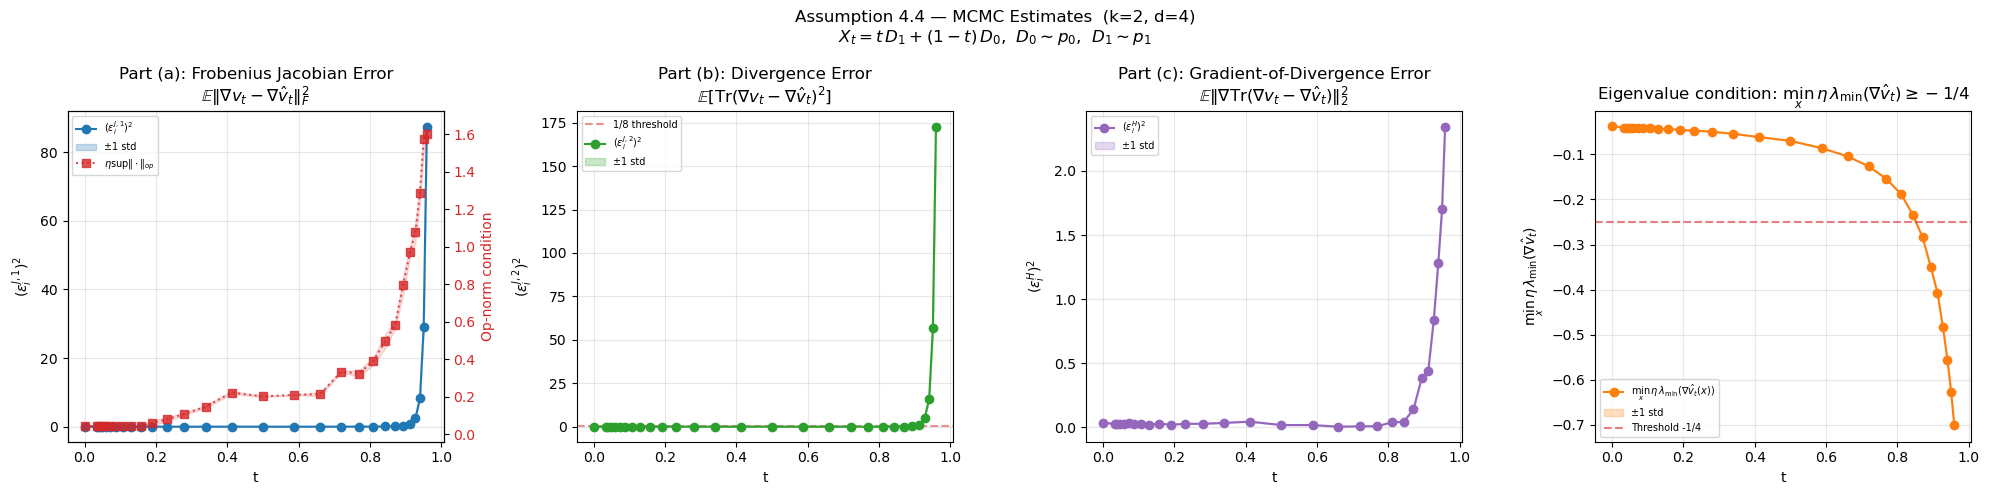


ASSUMPTION 4.4  —  MCMC SUMMARY
  N⁻¹Σ(εᵢᴶ·¹)²     = 4.441456 ± 0.018069
  N⁻¹Σ(εᵢᴶ·²)²     = 8.675095 ± 0.041171
  N⁻¹Σ(εᵢᴴ)²       = 0.264712  ± 0.001962
  sup op-norm ≤ 1/8? ✗ FAIL  (max=1.6006)
  min η·λ_min ≥−1/4? ✗ FAIL  (min=-0.7010)


In [8]:
plot_assumption_4_4(results, k=RANK, d=INPUT_DIM)

In [9]:
results

{'time_grid': array([0.        , 0.03333333, 0.0404469 , 0.04907856, 0.05955227,
        0.07226114, 0.08768218, 0.10639418, 0.12909944, 0.15665018,
        0.19008043, 0.23064494, 0.2798662 , 0.33959162, 0.41206287,
        0.5       , 0.58793713, 0.66040838, 0.7201338 , 0.76935506,
        0.80991957, 0.84334982, 0.87090056, 0.89360582, 0.91231782,
        0.92773886, 0.94044773, 0.95092144, 0.9595531 ]),
 'mean_a': array([3.62913511e-02, 1.46593898e-02, 1.52035140e-02, 1.37385312e-02,
        1.61880206e-02, 1.34293702e-02, 1.26677851e-02, 1.24392582e-02,
        1.52942816e-02, 1.44398316e-02, 1.53896811e-02, 1.23539993e-02,
        1.14798186e-02, 1.16181239e-02, 2.06514333e-02, 1.63907757e-02,
        8.31471972e-03, 1.41686305e-02, 2.06830291e-02, 2.83964590e-02,
        4.40017437e-02, 8.17720222e-02, 1.26074969e-01, 1.97754298e-01,
        6.90357130e-01, 2.56009372e+00, 8.25642186e+00, 2.91525878e+01,
        8.73693540e+01]),
 'std_a': array([3.36536471e-03, 1.48386503e-03, 